# Assignment 6:

## Task 1: Classification using Distance from Class Means


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [ ]:
n1=100
n2=100
np.random.seed(42)

mean_1=np.array([-1.5,-1])
mean_2=np.array([1.5,1])
cov = np.eye(2)

X_class1 = np.random.multivariate_normal(mean_1, cov, size=n1)
y_class1 = np.zeros(n1, dtype=int)

X_class2 = np.random.multivariate_normal(mean_2, cov, size=n2)
y_class2 = np.ones(n2, dtype=int)

X = np.vstack((X_class1, X_class2))
y = np.concatenate((y_class1, y_class2))


In [ ]:
print("X_class1 data:",X_class1)
print("X_class2 data:",X_class2)

X_class1 data: [[-1.00328585e+00 -1.13826430e+00]
 [-8.52311462e-01  5.23029856e-01]
 [-1.73415337e+00 -1.23413696e+00]
 [ 7.92128155e-02 -2.32565271e-01]
 [-1.96947439e+00 -4.57439956e-01]
 [-1.96341769e+00 -1.46572975e+00]
 [-1.25803773e+00 -2.91328024e+00]
 [-3.22491783e+00 -1.56228753e+00]
 [-2.51283112e+00 -6.85752667e-01]
 [-2.40802408e+00 -2.41230370e+00]
 [-3.43512311e-02 -1.22577630e+00]
 [-1.43247180e+00 -2.42474819e+00]
 [-2.04438272e+00 -8.89077410e-01]
 [-2.65099358e+00 -6.24301982e-01]
 [-2.10063869e+00 -1.29169375e+00]
 [-2.10170661e+00  8.52278185e-01]
 [-1.51349722e+00 -2.05771093e+00]
 [-6.77455088e-01 -2.22084365e+00]
 [-1.29113640e+00 -2.95967012e+00]
 [-2.82818605e+00 -8.03138764e-01]
 [-7.61533420e-01 -8.28631719e-01]
 [-1.61564828e+00 -1.30110370e+00]
 [-2.97852199e+00 -1.71984421e+00]
 [-1.96063877e+00  5.71222262e-02]
 [-1.15638171e+00 -2.76304016e+00]
 [-1.17591603e+00 -1.38508228e+00]
 [-2.17692200e+00 -3.88323711e-01]
 [-4.69000478e-01 -6.87198809e-02]
 [-2.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(X_train.size)

280


In [ ]:
mu_1 = np.mean(X_train[y_train == 0], axis=0)
mu_2 = np.mean(X_train[y_train == 1], axis=0)

print(f"Estimated Mean Class 1: {mu_1}")
print(f"Estimated Mean Class 2: {mu_2}")

Estimated Mean Class 1: [-1.61297177 -1.02252954]
Estimated Mean Class 2: [1.67431934 0.97675897]


In [ ]:
def predict_ncm(X_pts, mu1, mu2):
    # Vectorized Euclidean distance computation
    dist_1 = np.sqrt(np.sum((X_pts - mu1) ** 2, axis=1))
    dist_2 = np.sqrt(np.sum((X_pts - mu2) ** 2, axis=1))
    return np.where(dist_1 <= dist_2, 0, 1)

# Evaluate on the test set
y_test_pred = predict_ncm(X_test, mu_1, mu_2)
test_accuracy = np.mean(y_test_pred == y_test) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 100.00%


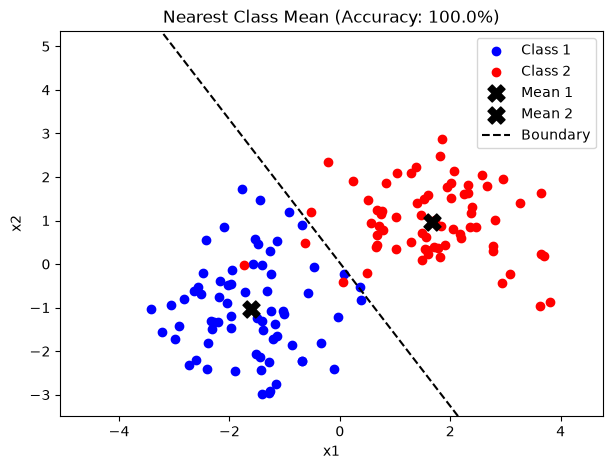

In [ ]:
# ------------------------------------------------------------------
# Step 5: Visualization (Simplified)
# ------------------------------------------------------------------
# Boundary equation: midpoint and perpendicular slope
midpoint = (mu_1 + mu_2) / 2
slope = -(mu_2[0] - mu_1[0]) / (mu_2[1] - mu_1[1])

x_line = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
y_line = slope * (x_line - midpoint[0]) + midpoint[1]

# Plot
plt.figure(figsize=(7, 5))

# 1. Training samples
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='blue', label='Class 1')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='red', label='Class 2')

# 2. Estimated class means
plt.scatter(mu_1[0], mu_1[1], color='black', marker='X', s=150, label='Mean 1')
plt.scatter(mu_2[0], mu_2[1], color='black', marker='X', s=150, label='Mean 2')

# 3. Decision boundary line
plt.plot(x_line, y_line, 'k--', label='Boundary')

plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Nearest Class Mean (Accuracy: {test_accuracy:.1f}%)')
plt.legend()
plt.show()

## Task 2: K-Nearest Neighbors Classification


In [ ]:
from scipy import stats

In [ ]:
def knn_predict(X_train_pts, y_train_labels, X_query_pts, k):
    """
    Predicts labels for X_query_pts using Euclidean distance and majority voting.
    """
    predictions = []
    for x in X_query_pts:
        # Compute Euclidean distance from query point to all training points
        distances = np.linalg.norm(X_train_pts - x, axis=1)
        
        # Get indices of the k smallest distances
        k_indices = np.argsort(distances)[:k]
        
        # Extract labels of the k nearest neighbors
        k_nearest_labels = y_train_labels[k_indices]
        
        # Majority voting (mode)
        mode_val = stats.mode(k_nearest_labels, keepdims=False)[0]
        predictions.append(mode_val)
        
    return np.array(predictions)

In [ ]:
K_values = [1, 3, 5, 11, 21]
accuracies_dataset1 = []

print("--- Dataset 1 (Task 1 Data) ---")
for k in K_values:
    y_pred = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(y_pred == y_test) * 100
    accuracies_dataset1.append(acc)
    print(f"K = {k:2d} -> Test Accuracy: {acc:.2f}%")

--- Dataset 1 (Task 1 Data) ---
K =  1 -> Test Accuracy: 93.33%
K =  3 -> Test Accuracy: 100.00%
K =  5 -> Test Accuracy: 100.00%
K = 11 -> Test Accuracy: 100.00%
K = 21 -> Test Accuracy: 100.00%


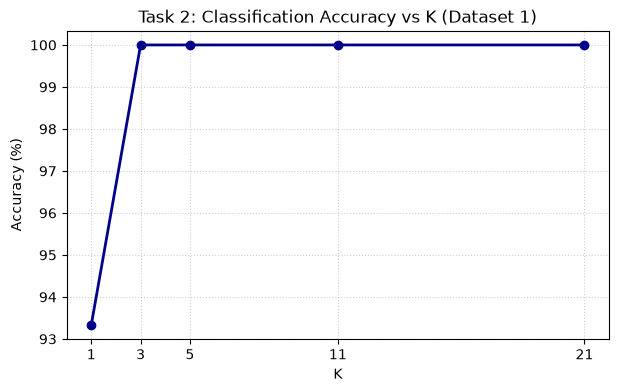

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(K_values, accuracies_dataset1, marker='o', color='darkblue', linewidth=2)
plt.title("Task 2: Classification Accuracy vs K (Dataset 1)")
plt.xlabel("K")
plt.ylabel("Accuracy (%)")
plt.xticks(K_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

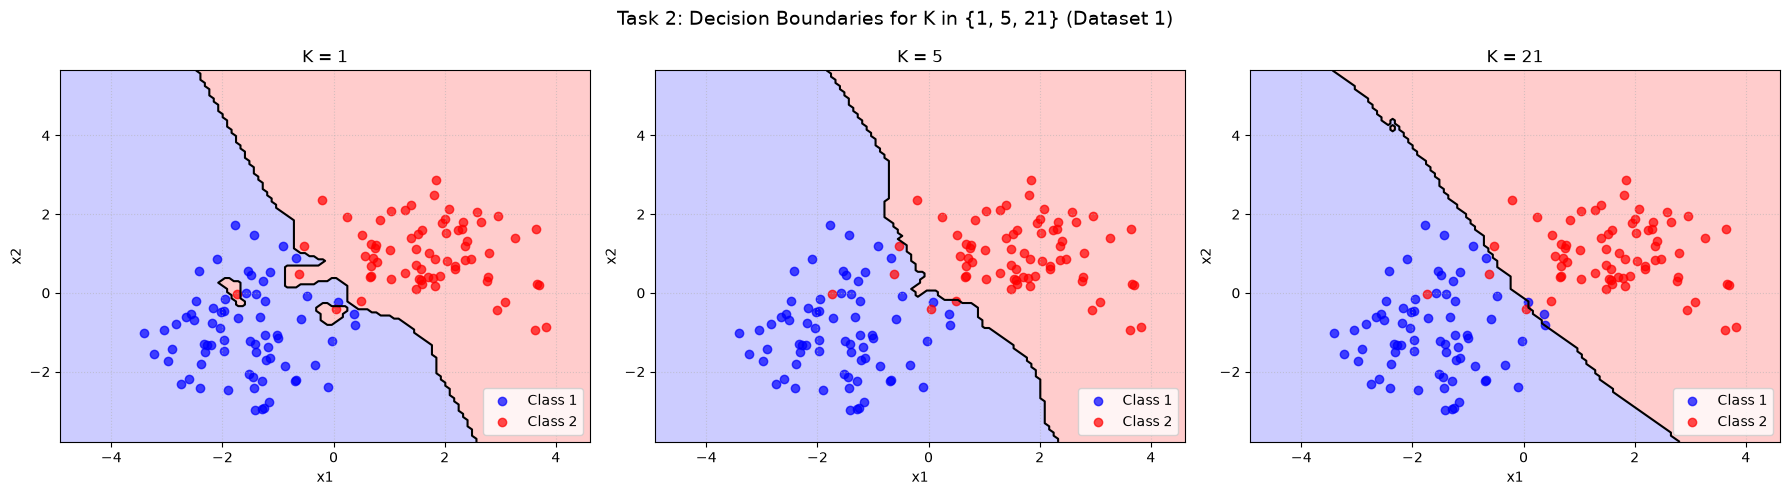

In [ ]:
x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120),
                     np.linspace(y_min, y_max, 120))
grid_points = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, k in enumerate([1, 5, 21]):
    # Predict over entire grid
    grid_preds = knn_predict(X_train, y_train, grid_points, k)
    zz = grid_preds.reshape(xx.shape)
    
    ax = axes[idx]
    # Decision boundary contour
    ax.contourf(xx, yy, zz, alpha=0.2, levels=[-0.5, 0.5, 1.5], colors=['blue', 'red'])
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)
    
    # Training points
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
               color='blue', label='Class 1', alpha=0.7)
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
               color='red', label='Class 2', alpha=0.7)
    
    ax.set_title(f"K = {k}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle("Task 2: Decision Boundaries for K in {1, 5, 21} (Dataset 1)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(42)

mean_1_new = np.array([-1.0, -0.5])
mean_2_new = np.array([1.0, 0.5])
cov = np.eye(2)

X2_c1 = np.random.multivariate_normal(mean_1_new, cov, size=100)
X2_c2 = np.random.multivariate_normal(mean_2_new, cov, size=100)

X2 = np.vstack((X2_c1, X2_c2))
y2 = np.concatenate((np.zeros(100, dtype=int), np.ones(100, dtype=int)))

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)

In [ ]:
mu1_d2 = np.mean(X2_train[y2_train == 0], axis=0)
mu2_d2 = np.mean(X2_train[y2_train == 1], axis=0)

d1 = np.linalg.norm(X2_test - mu1_d2, axis=1)
d2 = np.linalg.norm(X2_test - mu2_d2, axis=1)
y2_test_ncm_pred = np.where(d1 <= d2, 0, 1)
ncm_acc_d2 = np.mean(y2_test_ncm_pred == y2_test) * 100

print(f"\n--- Dataset 2 (Closer Means) ---")
print(f"Task 1 (NCM) Test Accuracy: {ncm_acc_d2:.2f}%")


--- Dataset 2 (Closer Means) ---
Task 1 (NCM) Test Accuracy: 88.33%


K =  1 -> Test Accuracy: 86.67%
K =  3 -> Test Accuracy: 85.00%
K =  5 -> Test Accuracy: 90.00%
K = 11 -> Test Accuracy: 91.67%
K = 21 -> Test Accuracy: 88.33%


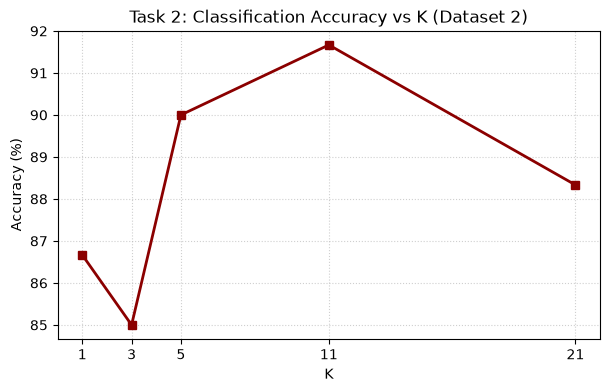

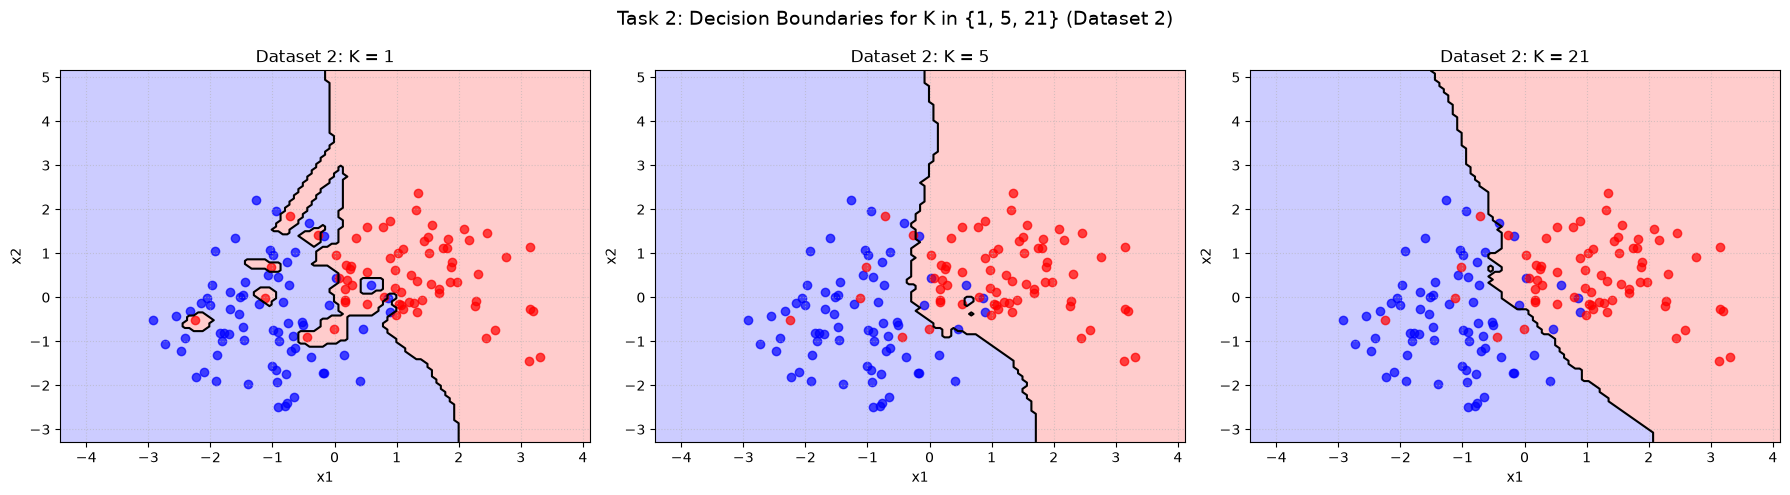

In [ ]:
accuracies_dataset2 = []
for k in K_values:
    y_pred2 = knn_predict(X2_train, y2_train, X2_test, k)
    acc2 = np.mean(y_pred2 == y2_test) * 100
    accuracies_dataset2.append(acc2)
    print(f"K = {k:2d} -> Test Accuracy: {acc2:.2f}%")

# Plot: Accuracy vs K for Dataset 2
plt.figure(figsize=(7, 4))
plt.plot(K_values, accuracies_dataset2, marker='s', color='darkred', linewidth=2)
plt.title("Task 2: Classification Accuracy vs K (Dataset 2)")
plt.xlabel("K")
plt.ylabel("Accuracy (%)")
plt.xticks(K_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Decision Boundaries for K = 1, 5, 21 on Dataset 2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_min, x_max = X2[:, 0].min() - 0.8, X2[:, 0].max() + 0.8
y_min, y_max = X2[:, 1].min() - 0.8, X2[:, 1].max() + 0.8
xx2, yy2 = np.meshgrid(np.linspace(x_min, x_max, 120),
                       np.linspace(y_min, y_max, 120))
grid_points2 = np.c_[xx2.ravel(), yy2.ravel()]

for idx, k in enumerate([1, 5, 21]):
    grid_preds = knn_predict(X2_train, y2_train, grid_points2, k)
    zz2 = grid_preds.reshape(xx2.shape)
    
    ax = axes[idx]
    ax.contourf(xx2, yy2, zz2, alpha=0.2, levels=[-0.5, 0.5, 1.5], colors=['blue', 'red'])
    ax.contour(xx2, yy2, zz2, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X2_train[y2_train == 0, 0], X2_train[y2_train == 0, 1], color='blue', alpha=0.7)
    ax.scatter(X2_train[y2_train == 1, 0], X2_train[y2_train == 1, 1], color='red', alpha=0.7)
    ax.set_title(f"Dataset 2: K = {k}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle("Task 2: Decision Boundaries for K in {1, 5, 21} (Dataset 2)", fontsize=14)
plt.tight_layout()
plt.show()


### Observations and Conclusions

* **Algorithmic Difference between Distance-from-Means and K-NN:** The Distance-from-Means classifier computes a single representative mean vector for each class during training and assigns a test point to the class with the closest mean. It inherently assumes the data follows a unimodal, roughly spherical distribution. In contrast, K-Nearest Neighbors (K-NN) is a non-parametric method that stores all training data and assigns a test point based on the majority class of its $K$ nearest individual neighbors. K-NN can capture complex, non-linear, and multimodal decision boundaries.
* **Decision Boundaries:** As observed in the plots, the Distance-from-Means classifier creates a strictly linear decision boundary. K-NN, however, creates highly non-linear and complex boundaries, especially for small values of $K$ (e.g., $K=1$), which can lead to overfitting by capturing noise. As $K$ increases (e.g., $K=21$), the K-NN boundary becomes smoother and more generalized.


## Task 3: K-NN Classification of MNIST


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from scipy import stats

# Load MNIST dataset
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all = mnist.data
y_all = mnist.target.astype(int)

# Randomly select 10,000 training and 2,000 test images using a fixed random seed
np.random.seed(42)
indices = np.random.choice(len(X_all), 12000, replace=False)
X_subset = X_all[indices]
y_subset = y_all[indices]

X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_subset, y_subset, train_size=10000, test_size=2000, random_state=42
)

# Scale pixel values to the range [0, 1]
X_train_mnist = X_train_mnist / 255.0
X_test_mnist = X_test_mnist / 255.0

print(f"X_train_mnist shape: {X_train_mnist.shape}")


In [ ]:
def knn_predict_mnist(X_train, y_train, X_query, k, p=2):
    """
    K-NN prediction for MNIST using Minkowski distance of order p.
    """
    predictions = []
    # Process queries in batches to optimize memory and speed
    batch_size = 500
    for i in range(0, len(X_query), batch_size):
        X_batch = X_query[i:i+batch_size]
        if p == 2:
            # Efficient squared euclidean distance calculation: x^2 + y^2 - 2xy
            train_sq = np.sum(X_train**2, axis=1)
            query_sq = np.sum(X_batch**2, axis=1)[:, np.newaxis]
            dot_prod = np.dot(X_batch, X_train.T)
            distances = np.sqrt(np.maximum(0, query_sq + train_sq - 2 * dot_prod))
        elif p == 1:
            # Manhattan distance (slower)
            distances = np.array([np.sum(np.abs(X_train - x), axis=1) for x in X_batch])
            
        k_indices = np.argsort(distances, axis=1)[:, :k]
        k_labels = y_train[k_indices]
        
        # Majority voting
        modes, _ = stats.mode(k_labels, axis=1, keepdims=False)
        predictions.extend(modes)
            
    return np.array(predictions)

K_vals_mnist = [1, 3, 5, 7, 9]
acc_mnist = []

for k in K_vals_mnist:
    y_pred = knn_predict_mnist(X_train_mnist, y_train_mnist, X_test_mnist, k, p=2)
    acc = np.mean(y_pred == y_test_mnist) * 100
    acc_mnist.append(acc)
    print(f"K = {k}, Test Accuracy = {acc:.2f}%")

# Plot test accuracy versus K
plt.figure(figsize=(7, 4))
plt.plot(K_vals_mnist, acc_mnist, marker='o', color='purple', linewidth=2)
plt.title("Task 3A: Classification Accuracy vs K (MNIST)")
plt.xlabel("K")
plt.ylabel("Accuracy (%)")
plt.xticks(K_vals_mnist)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

best_k = K_vals_mnist[np.argmax(acc_mnist)]


In [ ]:
# K = 5, Manhattan distance (p=1)
print("Running K-NN for K=5 with Manhattan distance (p=1)...")
y_pred_manhattan = knn_predict_mnist(X_train_mnist, y_train_mnist, X_test_mnist, k=5, p=1)
acc_manhattan = np.mean(y_pred_manhattan == y_test_mnist) * 100

# K = 5, Euclidean distance (p=2) - already computed above, but let's re-run for clarity
print("Running K-NN for K=5 with Euclidean distance (p=2)...")
y_pred_euclidean = knn_predict_mnist(X_train_mnist, y_train_mnist, X_test_mnist, k=5, p=2)
acc_euclidean = np.mean(y_pred_euclidean == y_test_mnist) * 100

print(f"\nAccuracy with Manhattan distance (p=1): {acc_manhattan:.2f}%")
print(f"Accuracy with Euclidean distance (p=2): {acc_euclidean:.2f}%")

# Display 5 test images with true digit and predicted digits
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    idx = i # taking first 5 images from test set
    image = X_test_mnist[idx].reshape(28, 28)
    axes[i].imshow(image, cmap='gray')
    axes[i].axis('off')
    title = (f"True: {y_test_mnist[idx]}\n"
             f"Pred (p=1): {y_pred_manhattan[idx]}\n"
             f"Pred (p=2): {y_pred_euclidean[idx]}")
    axes[i].set_title(title, fontsize=10)

plt.tight_layout()


### Observations on MNIST Classification

* **Effect of K:** As K increases from 1, the accuracy might initially improve by filtering out noise, but for the MNIST dataset with Euclidean distance, smaller values of $K$ (like $K=1$ or $K=3$) often perform exceptionally well because similar digits map to tight, dense clusters in the feature space. Higher values of $K$ can cause the decision boundary to become overly smoothed, potentially allowing more frequent or diffuse classes to dominate local neighborhoods and reducing accuracy.
